<a href="https://colab.research.google.com/github/BasuAI/BasuAI/blob/main/GWPZ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Machine learning algorithms for groundwater potential zone mapping **
*Learning Objective: Tree algorithm application for classfication *
Step 1: Import neccsary pakages

In [13]:
## Step 1: Import neccsary pakages
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn import metrics, svm
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes  import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import cohen_kappa_score

In [14]:
!pip install rasterio

In [15]:
import rasterio

In [58]:
raster_files = ['/content/clay.tif',
                '/content/curve.tif',
                '/content/dd.tif',
                '/content/NDVI.tif',
                '/content/NDWI.tif',
                '/content/rainfall.tif',
                '/content/temp.tif',
                '/content/sand.tif',
                '/content/slope.tif',
                '/content/elevation.tif']

# Initialize an empty list to store raster data
raster_data = []


In [49]:
in_img_clay= r'/content/clay.tif'
in_img_curve = r'/content/curve.tif'
in_img_dd = r'/content/dd.tif'
in_img_NDVI = r'/content/NDVI.tif'
in_img_NDWI = r'/content/NDWI.tif'
in_img_rainfall = r'/content/rainfall.tif'
in_img_temp = r'/content/temp.tif'
in_img_sand = r'/content/sand.tif'
in_img_slope = r'/content/slope.tif'
in_img_elevation = r'/content/elevation.tif'



In [50]:
ds = rasterio.open (in_img_clay)
ds
data = ds.read()
data

array([[[-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38],
        [-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38],
        [-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38],
        ...,
        [-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38],
        [-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38],
        [-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38]]], dtype=float32)

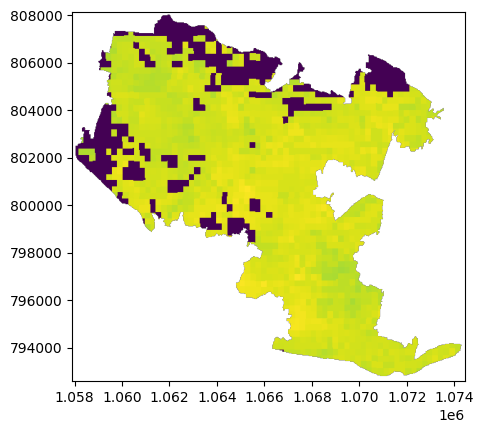

In [51]:
with rasterio.open(in_img_clay) as ds:  # Using 'with' statement to ensure proper closing
    # Display the raster data using show() function
    show(ds)

In [53]:
ds = rasterio.open (in_img_elevation)
ds
data = ds.read()
data

array([[[-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38],
        [-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38],
        [-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38],
        ...,
        [-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38],
        [-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38],
        [-3.402823e+38, -3.402823e+38, -3.402823e+38, ...,
         -3.402823e+38, -3.402823e+38, -3.402823e+38]]], dtype=float32)

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


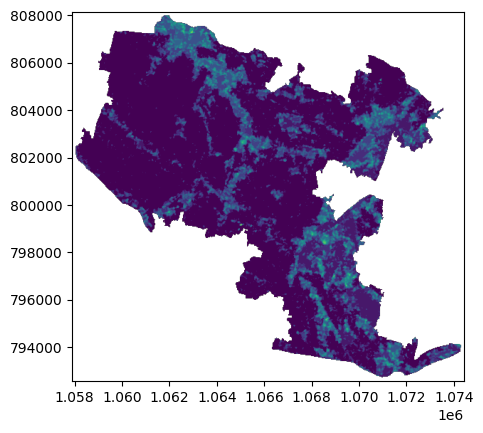

In [54]:
with rasterio.open(in_img_elevation) as ds:  # Using 'with' statement to ensure proper closing
    # Display the raster data using show() function
    show(ds)

In [61]:
raster_path = ['/content/clay.tif',
                '/content/curve.tif',
                '/content/dd.tif',
                '/content/NDVI.tif',
                '/content/NDWI.tif',
                '/content/rainfall.tif',
                '/content/temp.tif',
                '/content/sand.tif',
                '/content/slope.tif',
                '/content/elevation.tif']

# Initialize an empty list to store raster data
raster_data = []

# Iterate through the list of file paths
for file_path in raster_path:
    with rasterio.open(file_path) as src:
        # Read the first band of each raster
        band_data = src.read(1)

        # Check if this is the first raster, if so, store its shape
        if not raster_data:
            first_shape = band_data.shape
        # Check if the current raster shape matches the first raster's shape
        elif band_data.shape != first_shape:
            print(f"Warning: Raster {file_path} has a different shape ({band_data.shape}) than the first raster ({first_shape}). Skipping.")
            continue  # Skip this raster if it has a different shape

        # Append the band data to the list
        raster_data.append(band_data)

# Stack the bands into a single array (optional)
# Only stack if there is data in raster_data
if raster_data:
    raster_data = np.stack(raster_data, axis=0)
else:
    print("No rasters with matching shapes found.")

In [64]:
for file_path in raster_path:
    with rasterio.open(file_path) as src:
        # Read the data (e.g., first band) and get the extent
        raster_data = src.read(1)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

        # Now you have 'raster_data' and 'extent' for the current file
        # Process them as needed
        print(f"Processing {file_path}:")
        print(f"Raster data shape: {raster_data.shape}")
        print(f"Extent: {extent}")

Processing /content/clay.tif:
Raster data shape: (519, 551)
Extent: [1057913.9285514653, 1074443.9285514653, 792586.2978840421, 808156.2978840421]
Processing /content/curve.tif:
Raster data shape: (520, 551)
Extent: [1057908.9180553728, 1074438.9180553728, 792564.9163776065, 808164.9163776065]
Processing /content/dd.tif:
Raster data shape: (522, 560)
Extent: [1057788.981178665, 1074588.981178665, 792527.3027436839, 808187.3027436839]
Processing /content/NDVI.tif:
Raster data shape: (520, 550)
Extent: [1057928.7600672184, 1074428.7600672184, 792575.7782747939, 808175.7782747939]
Processing /content/NDWI.tif:
Raster data shape: (520, 550)
Extent: [1057928.7600672184, 1074428.7600672184, 792575.7782747939, 808175.7782747939]
Processing /content/rainfall.tif:
Raster data shape: (520, 550)
Extent: [1057935.9667456343, 1074435.9667456343, 792576.4086659194, 808176.4086659194]
Processing /content/temp.tif:
Raster data shape: (519, 551)
Extent: [1057916.290415962, 1074446.290415962, 792581.777

In [65]:
# Normalize the raster data (if required)
raster_data = np.where(raster_data == src.nodata, np.nan, raster_data)
normalized_data = (raster_data - np.nanmin(raster_data)) / (np.nanmax(raster_data) - np.nanmin(raster_data))


In [73]:
# Classify into groundwater potential zones (Example: 5 classes)
classified = np.digitize(normalized_data, bins=np.linspace(0, 1, 6))

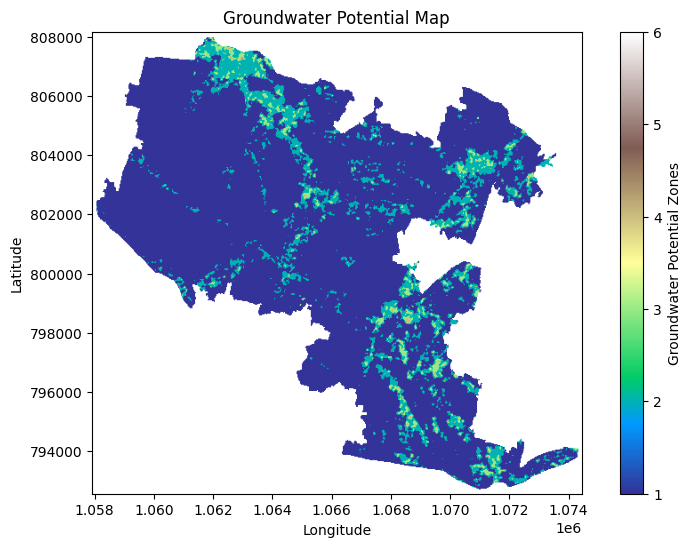

In [74]:
import matplotlib.pyplot as plt # Import the pyplot module as plt

# Plot the results
plt.figure(figsize=(10, 6))
plt.imshow(classified, cmap="terrain", extent=extent)
plt.colorbar(label="Groundwater Potential Zones")
plt.title("Groundwater Potential Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [86]:
# Step 5: Save Output as Raster
output_file = "groundwater_potential_zone.tif"

**RF model**

In [77]:
# Read each raster file
raster_data_list = []  # Create a new list to store the data
shapes = [] # Create a list to store shapes of each raster

for file in raster_files:
    with rasterio.open(file) as src:
        raster_data_list.append(src.read(1))  # Read first band and append to the list
        shapes.append(src.read(1).shape) # Store shape of the raster data
        profile = src.profile  # Store profile for output

# Check if all shapes are the same
if len(set(shapes)) != 1:
    print("Error: Rasters have different shapes. Cannot create a single NumPy array.")
    print("Shapes:", shapes)
else:
    # Now, you can convert the list to a NumPy array if needed:
    raster_data = np.array(raster_data_list)
    print("Raster data shape:", raster_data.shape)

Error: Rasters have different shapes. Cannot create a single NumPy array.
Shapes: [(519, 551), (520, 551), (522, 560), (520, 550), (520, 550), (520, 550), (519, 551), (519, 551), (520, 551), (520, 551)]


In [78]:
# Stack raster arrays
stacked_raster = np.dstack(raster_data)

In [79]:
# Convert NoData values to NaN
stacked_raster[stacked_raster == profile['nodata']] = np.nan

In [90]:
!pip install geopandas
import geopandas as gpd
import os
 # Import the geopandas library and assign it the alias 'gpd'


In [141]:
# Step 2: Prepare Training Data
# Load sample groundwater points (training labels)
groundwater_points = gpd.read_file("/content/GWPZ_points.shp")

In [146]:
# Extract values at known groundwater locations
training_samples = ["/content/GWPZ_points.shp"]
training_labels = ["/content/GWPZ_points.shp"]

In [147]:
for _, point in groundwater_points.iterrows():
    # Transform coordinates to the raster's coordinate system
    x, y = point.geometry.x, point.geometry.y
    row, col = src.index(x, y)

    # Check if row and col are within the raster bounds
    if 0 <= row < stacked_raster.shape[1] and 0 <= col < stacked_raster.shape[2]:
        training_samples.append(stacked_raster[0, row, col]) # Access data using 3D indexing
        training_labels.append(point["potential"])  # 0 (Low) - 1 (High)


In [150]:
training_samples = np.array(training_samples)
training_labels = np.array(training_labels)

In [149]:
# Step 3: Train the Random Forest Model
X_train, X_test, y_train, y_test = train_test_split(training_samples, training_labels, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

ValueError: With n_samples=1, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [128]:
# Evaluate Model Accuracy
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

NameError: name 'X_test' is not defined

**Import the ground water features**

In [ ]:
#Step 1: Read and explore data
file='E:/kidi file e/PAPERS/GWPM/nn.csv'
raw_data = pd.read_csv(file, parse_dates = ['POINT'],
                       index_col = 'POINT')
df = raw_data.copy()
df

**Data pre processing**

In [ ]:
import numpy as np
# Replace all -9999s with NaNs to make it easier to work with
df.replace(to_replace=-9999, value=np.nan, inplace=True)
# Check missing values
df.isnull().sum()


# Check missing values
df.isnull().sum()
# Replace missing values by interpolation

def replace_missing (attribute):
    return attribute.interpolate(inplace=True)
replace_missing(df['GEOMORPHOLOGY'])
replace_missing(df['DD'])
replace_missing(df['LD'])
replace_missing(df['LULC'])
replace_missing(df['NDVI'])
replace_missing(df['SLOPE '])
replace_missing(df['SOIL'])
replace_missing(df['RF'])
replace_missing(df['TWI'])
replace_missing(df['TRI'])
replace_missing(df['GWPZ'])
replace_missing(df['GEOLOGY'])

df

seed = 42
np.random.seed(seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)

ebm = ExplainableBoostingClassifier()
ebm.fit(X_train, y_train)

auc = roc_auc_score(y_test, ebm.predict_proba(X_test)[:, 1])
print("AUC: {:.3f}".format(auc))

In [ ]:
#df.to_excel("C:/Users/User/Desktop/GWPM/missing out.xlsx",index=False)

# Read data from  csv files
X = df.drop(["GWPZ"], axis=1)
y = df["GWPZ"]
Input_data_features = X.values
Input_data_labels =y.values


# standardize input features X and output labels Y
#scaler_standardized_X = StandardScaler()
#Input_data_features = scaler_standardized_X.fit_transform(Input_data_features)

#scaler_standardized_Y = StandardScaler()
#Input_data_labels = scaler_standardized_Y.fit_transform(Input_data_labels)


# Split dataset into train, validation, an test
index_X_Train_End = int(0.7 * len(Input_data_features))
index_X_Validation_End = int(0.9 * len(Input_data_features))

X_train = Input_data_features[0: index_X_Train_End]
X_valid = Input_data_features[index_X_Train_End: index_X_Validation_End]
X_test = Input_data_features[index_X_Validation_End:]

Y_train = Input_data_labels[0: index_X_Train_End]
Y_valid = Input_data_labels[index_X_Train_End: index_X_Validation_End]
Y_test = Input_data_labels[index_X_Validation_End:]

method 1: random forest model

In [ ]:
#method 1: random forest model and train it
model_randomForest = RandomForestClassifier()
model_randomForest.fit(X_train, Y_train)
rfr = model_randomForest.predict(X_test)
#print(f"Random Forest Prediction: {rfr}")
print("Accuracy RandomForestClassifier: ", accuracy_score(Y_test, rfr))
#print("precision_recall_fscore RandomForestClassifier:",precision_recall_fscore_support(Y_test, rfr, average='weighted'))
precision_positive = metrics.precision_score(Y_test, rfr, pos_label=1,average='micro')
precision_negative = metrics.precision_score(Y_test, rfr, pos_label=0,average='micro')
recall_sensitivity = metrics.recall_score(Y_test, rfr, pos_label=1,average='micro')
recall_specificity = metrics.recall_score(Y_test, rfr, pos_label=0,average='micro')
f1_positive = metrics.f1_score(Y_test, rfr, pos_label=1,average='micro' )
f1_negative = metrics.f1_score(Y_test, rfr, pos_label=1,average='micro')
print(metrics.classification_report(Y_test, rfr))
print("kappa Randomforest: ",cohen_kappa_score(Y_test, rfr))

method:2 Gradient boosting model

In [ ]:
#method:2gradient boosting  model and train it (-->Here I get the ValueError)
model_gradientBoosting = GradientBoostingClassifier( )
model_gradientBoosting.fit(X_train, Y_train)
GBP = model_gradientBoosting.predict(X_test)
#print(f"Gradient Boosting Prediction: {Y_pred_gradientBoosting}")
print("Accuracy GradientBoostingClassifier: ", accuracy_score(Y_test, GBP))
#print("precision_recall_fscore GradientBoostingClassifier:",precision_recall_fscore_support(Y_test, GBP, average='weighted'))
precision_positive = metrics.precision_score(Y_test, GBP, pos_label=1,average='micro')
precision_negative = metrics.precision_score(Y_test, GBP, pos_label=0,average='micro')
recall_sensitivity = metrics.recall_score(Y_test, GBP, pos_label=1,average='micro')
recall_specificity = metrics.recall_score(Y_test, GBP, pos_label=0,average='micro')
f1_positive = metrics.f1_score(Y_test, GBP, pos_label=1,average='micro' )
f1_negative = metrics.f1_score(Y_test, GBP, pos_label=1,average='micro')
print(metrics.classification_report(Y_test, GBP))
print("kappa GradientBoosting: ",cohen_kappa_score(Y_test, GBP))

Method 3:Decsion tree classifier

In [ ]:
#Method 3:Decsion tree classifier
clf = DecisionTreeClassifier()
clf.fit(X_train, Y_train)
#print("DecisionTreeClassifier")
#print(clf.predict(X_test))
DTC = clf.predict(X_test)
print("Accuracy Decsion tree classifier  : ", accuracy_score(Y_test, DTC))
#print("precision_recall_fscore Decsion tree classifier:",precision_recall_fscore_support(Y_test, DTC, average='weighted'))
precision_positive = metrics.precision_score(Y_test, DTC, pos_label=1,average='micro')
precision_negative = metrics.precision_score(Y_test, DTC, pos_label=0,average='micro')
recall_sensitivity = metrics.recall_score(Y_test, DTC, pos_label=1,average='micro')
recall_specificity = metrics.recall_score(Y_test,  DTC, pos_label=0,average='micro')
f1_positive = metrics.f1_score(Y_test,  DTC, pos_label=1,average='micro' )
f1_negative = metrics.f1_score(Y_test,  DTC, pos_label=1,average='micro')
print(metrics.classification_report(Y_test,  DTC))
print("kappa Decsion tree classifier: ",cohen_kappa_score(Y_test, DTC))

Method 4: kneighbors classifier

In [ ]:
#Method 4:  kneighbors classifier
clf = KNeighborsClassifier()
clf.fit(X_train, Y_train)
#print("KNeighborsClassifier")
#print(clf.predict(X_test))
KNC = clf.predict(X_test)
print("Accuracy KNeighborsClassifier : ", accuracy_score(Y_test, KNC))
#print("precision_recall_fscore KNeighborsClassifier:",precision_recall_fscore_support(Y_test, KNC, average='weighted'))
precision_positive = metrics.precision_score(Y_test, KNC, pos_label=1,average='micro')
precision_negative = metrics.precision_score(Y_test, KNC, pos_label=0,average='micro')
recall_sensitivity = metrics.recall_score(Y_test, KNC, pos_label=1,average='micro')
recall_specificity = metrics.recall_score(Y_test,  KNC, pos_label=0,average='micro')
f1_positive = metrics.f1_score(Y_test,  KNC, pos_label=1,average='micro' )
f1_negative = metrics.f1_score(Y_test,  KNC, pos_label=1,average='micro')
print(metrics.classification_report(Y_test,  KNC))
print("kappa KNeighbors: ",cohen_kappa_score(Y_test, KNC))

Method 5:Lineardiscriminatanalysis

In [ ]:
clf = LinearDiscriminantAnalysis()
clf.fit(X_train, Y_train)
LDA = clf.predict(X_test)
print("Accuracy Lineardiscriminatanalysis : ", accuracy_score(Y_test, LDA))
#print("precision_recall_fscore Lineardiscriminatanalysis:",precision_recall_fscore_support(Y_test, LDA, average='weighted'))
precision_positive = metrics.precision_score(Y_test, LDA, pos_label=1,average='micro')
precision_negative = metrics.precision_score(Y_test, LDA, pos_label=0,average='micro')
recall_sensitivity = metrics.recall_score(Y_test, LDA, pos_label=1,average='micro')
recall_specificity = metrics.recall_score(Y_test,  LDA, pos_label=0,average='micro')
f1_positive = metrics.f1_score(Y_test,  LDA, pos_label=1,average='micro' )
f1_negative = metrics.f1_score(Y_test,  LDA, pos_label=1,average='micro')
print(metrics.classification_report(Y_test,  LDA))
print("kappa Lineardiscrimina: ",cohen_kappa_score(Y_test, LDA))

Method 6:GaussianNB

In [ ]:
clf = GaussianNB()
clf.fit(X_train, Y_train)
GANB = clf.predict(X_test)
print("Accuracy GaussianNB: ", accuracy_score(Y_test, GANB))
#print("precision_recall_fscore GaussianNB:",precision_recall_fscore_support(Y_test, GANB, average='weighted'))
precision_positive = metrics.precision_score(Y_test, GANB, pos_label=1,average='micro')
precision_negative = metrics.precision_score(Y_test, GANB, pos_label=0,average='micro')
recall_sensitivity = metrics.recall_score(Y_test, GANB, pos_label=1,average='micro')
recall_specificity = metrics.recall_score(Y_test,  GANB, pos_label=0,average='micro')
f1_positive = metrics.f1_score(Y_test,  GANB, pos_label=1,average='micro' )
f1_negative = metrics.f1_score(Y_test, GANB, pos_label=1,average='micro')
print(metrics.classification_report(Y_test,  GANB))
print("kappa GaussianNB: ",cohen_kappa_score(Y_test, GANB))

Method 7:SVC

In [ ]:
#Method 7:SVC
clf = SVC()
clf.fit(X_train, Y_train)
SVC = clf.predict(X_test)
print("Accuracy Support Vector Classifier: ", accuracy_score(Y_test, SVC))
#print("precision_recall_fscore Support Vector Classifier:",precision_recall_fscore_support(Y_test, SVC, average='weighted'))
precision_positive = metrics.precision_score(Y_test, SVC, pos_label=1,average='micro')
precision_negative = metrics.precision_score(Y_test, SVC, pos_label=0,average='micro')
recall_sensitivity = metrics.recall_score(Y_test, SVC, pos_label=1,average='micro')
recall_specificity = metrics.recall_score(Y_test,  SVC, pos_label=0,average='micro')
f1_positive = metrics.f1_score(Y_test,  SVC, pos_label=1,average='micro' )
f1_negative = metrics.f1_score(Y_test, SVC, pos_label=1,average='micro')
print(metrics.classification_report(Y_test,  SVC))
print("kappa SVC: ",cohen_kappa_score(Y_test, SVC))

ROC Curve

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

df = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None)
df.columns = [
    "Age", "WorkClass", "fnlwgt", "Education", "EducationNum",
    "MaritalStatus", "Occupation", "Relationship", "Race", "Gender",
    "CapitalGain", "CapitalLoss", "HoursPerWeek", "NativeCountry", "Income"
]
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

seed = 42
np.random.seed(seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)

ebm = ExplainableBoostingClassifier()
ebm.fit(X_train, y_train)

auc = roc_auc_score(y_test, ebm.predict_proba(X_test)[:, 1])
print("AUC: {:.3f}".format(auc))